## Fast Fourier Transforms (FFTs)

A key method very useful in determining the frequency or frequencies present in "time series" data.   
- It's what you use to determine relevant frequencies in repetitive behavior.   
- It is **not** a new kind of Fourier transform from classical mechanics or diffeq. It is just an efficient method  
for computing it on a computer.

We will (or attempt to):

- Introduce what a **discrete Fourier transform (DFT)** does.
- See how the **Fast Fourier Transform (FFT)** computes the DFT efficiently.
- Learn how to use `numpy.fft.fft` to go from **time domain** to **frequency domain**.
- Interpret basic **amplitude spectra** and understand **Nyquist frequency** and **aliasing**.


## 1. From time domain to frequency domain

Suppose we have a signal sampled at equally spaced times:

- Sample values: $x_0, x_1, \dots, x_{N-1}$
- Sampling interval: $\Delta t$
- Total duration: $T = N \Delta t$

The **discrete Fourier transform (DFT)** produces complex numbers $X_k$ such that

$$
X_k = \sum_{n=0}^{N-1} x_n \, e^{-2\pi i kn / N}, \quad k = 0, 1, \dots, N-1.
$$

Each $X_k$ tells us **how much of frequency** $f_k$ is present in the signal, where

$$
f_k = \frac{k}{T} = \frac{k}{N \Delta t}.
$$

- The **magnitude** $|X_k|$ tells you how strong that frequency component is.
- The **phase** $\arg(X_k)$ tells you the phase shift of that sinusoid.

Computing this formula directly takes $\mathcal{O}(N^2)$ operations. (As $N$ grows, the computation time grows rapidly.)   
The **Fast Fourier Transform (FFT)** is an algorithm that computes the same result in $\mathcal{O}(N \log N)$ time,  that is, **much** more rapidly.

We will not derive the algorithm here - instead, we will **use** it and learn to interpret the output.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit nicer and to minimize typing by setting some defaults
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 12


## 2. A simple sine wave example

We start with a single sine wave of known frequency and see what its FFT looks like.

Let's define:

- Sampling rate $f_s = 1000 \,\text{Hz}$ (1000 samples per second)
- Signal frequency $f_0 = 50 \,\text{Hz}$
- Duration $T = 1.0 \,\text{s}$

We will generate the signal

$$
x(t) = \sin(2\pi f_0 t)
$$

and plot it in the time domain.


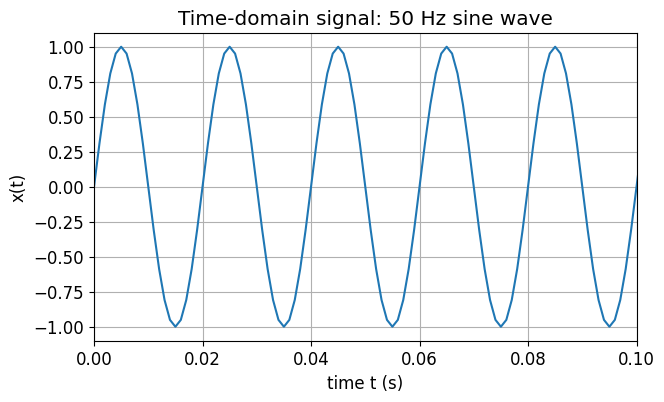

In [2]:
# Parameters
fs = 1000.0  # sampling frequency in Hz
T = 1.0      # total duration in seconds
f0 = 50.0    # signal frequency in Hz

N = int(fs * T)           # total number of samples
t = np.linspace(0, T, N, endpoint=False)  # time array
x = np.sin(2 * np.pi * f0 * t)            # signal

# Plot the time-domain signal (zooming into the first 0.1 s)
plt.figure()
plt.plot(t, x)
plt.xlim(0, 0.1)
plt.xlabel("time t (s)")
plt.ylabel("x(t)")
plt.title("Time-domain signal: 50 Hz sine wave")
plt.grid(True)
plt.show()


## 3. FFT of a sine wave

We now compute the FFT using `numpy.fft.fft`:

```python
X = np.fft.fft(x)
```

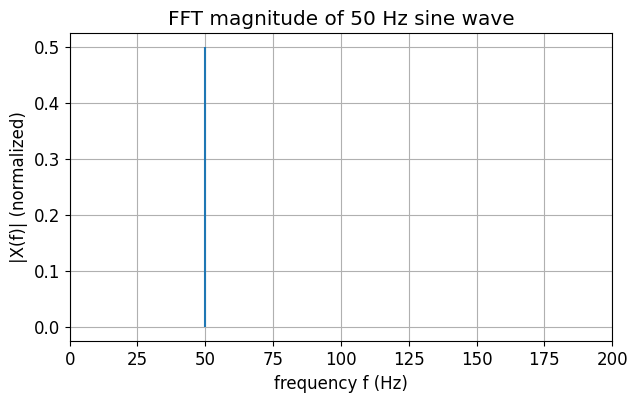

In [3]:

# Compute FFT
X = np.fft.fft(x)
freqs = np.fft.fftfreq(N, d=1/fs)

# Take magnitude
X_mag = np.abs(X) / N  # normalize by N so amplitude is comparable

# Only keep the non-negative frequencies
mask = freqs >= 0
freqs_pos = freqs[mask]
X_mag_pos = X_mag[mask]

plt.figure()
plt.stem(freqs_pos, X_mag_pos, linefmt='-', markerfmt=' ', basefmt=' ')
plt.xlim(0, 200)  # focus on low frequencies
plt.xlabel("frequency f (Hz)")
plt.ylabel("|X(f)| (normalized)")
plt.title("FFT magnitude of 50 Hz sine wave")
plt.grid(True)
plt.show()


## 4. Sum of two sine waves + noise

Now let's consider a more interesting signal:

$$
x(t) = \sin(2\pi f_1 t) + 0.5 \sin(2\pi f_2 t) + \text{noise}
$$

where

- $f_1 = 50 \,\text{Hz}$)
- $f_2 = 120 \,\text{Hz}$
- Noise is small random Gaussian noise

We will plot the time series and the FFT magnitude, and see how we can **identify the frequencies** present in the signal.


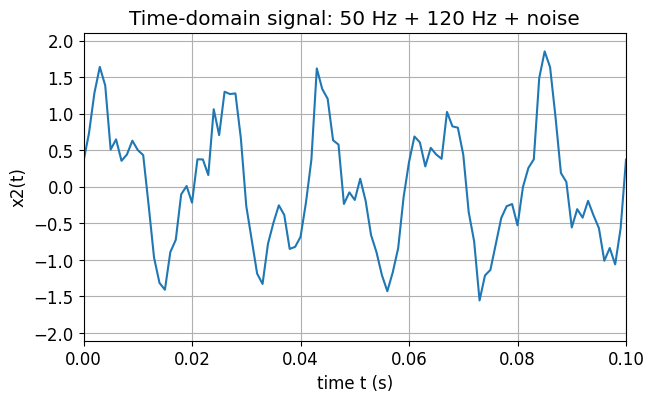

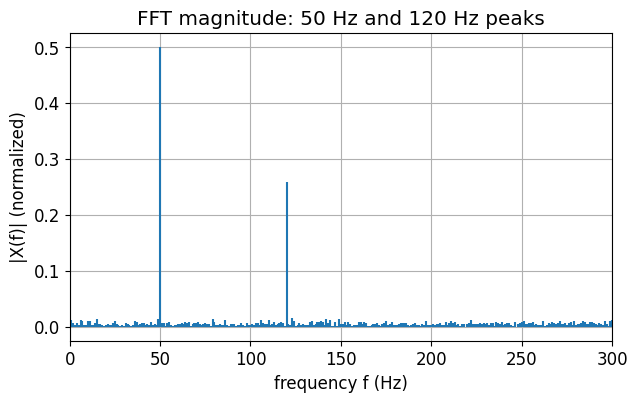

In [4]:
# New parameters
f1 = 50.0   # Hz
f2 = 120.0  # Hz

np.random.seed(0)  # for reproducibility
noise = 0.2 * np.random.randn(N)

x2 = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t) + noise

# Time-domain plot (short window)
plt.figure()
plt.plot(t, x2)
plt.xlim(0, 0.1)
plt.xlabel("time t (s)")
plt.ylabel("x2(t)")
plt.title("Time-domain signal: 50 Hz + 120 Hz + noise")
plt.grid(True)
plt.show()

# FFT
X2 = np.fft.fft(x2)
X2_mag = np.abs(X2) / N
freqs = np.fft.fftfreq(N, d=1/fs)
mask = freqs >= 0
freqs_pos = freqs[mask]
X2_mag_pos = X2_mag[mask]

plt.figure()
plt.stem(freqs_pos, X2_mag_pos, linefmt='-', markerfmt=' ', basefmt=' ')
plt.xlim(0, 300)
plt.xlabel("frequency f (Hz)")
plt.ylabel("|X(f)| (normalized)")
plt.title("FFT magnitude: 50 Hz and 120 Hz peaks")
plt.grid(True)
plt.show()


## 5. Nyquist frequency and aliasing

When we sample at rate $f_s$ (samples per second), the highest frequency we can **unambiguously** represent is the **Nyquist frequency**:

$$
f_{\text{Nyquist}} = \frac{f_s}{2}.
$$

Frequencies higher than $f_{\text{Nyquist}}$ will **alias** (fold) into lower frequencies and appear at the wrong location in the FFT.

### Example: Aliasing

We take two sampling rates:

- Case A: $f_s = 1000 \,\text{Hz}$)
- Case B: $f_s = 100 \,\text{Hz}$

and a signal frequency $f_0 = 80 \,\text{Hz}$.  

- In Case A, $f_0 < f_{\text{Nyquist}} = 500 \,\text{Hz}$: no aliasing.
- In Case B, $f_0 > f_{\text{Nyquist}} = 50 \,\text{Hz}$: we will see aliasing.


![alias.png](alias.png)

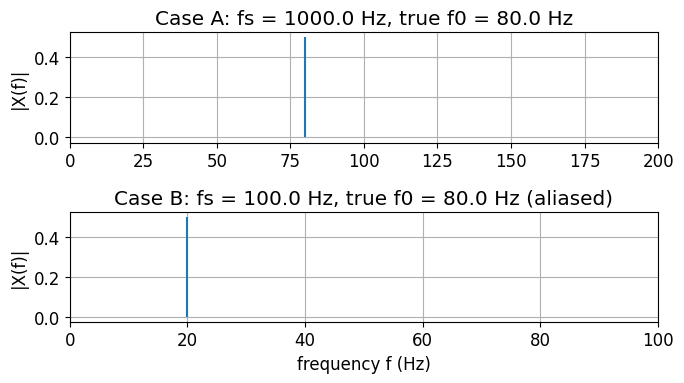

In [8]:
def make_signal_and_fft(fs, f0, T=1.0):
    N = int(fs * T)
    t = np.linspace(0, T, N, endpoint=False)
    x = np.sin(2 * np.pi * f0 * t)
    X = np.fft.fft(x)
    freqs = np.fft.fftfreq(N, d=1/fs)
    X_mag = np.abs(X) / N
    mask = freqs >= 0
    return t, x, freqs[mask], X_mag[mask]

f0 = 80.0  # Hz

# Case A: high sampling rate
fs_A = 1000.0
tA, xA, fA, XA = make_signal_and_fft(fs_A, f0)

# Case B: low sampling rate
fs_B = 100.0
tB, xB, fB, XB = make_signal_and_fft(fs_B, f0)

# Plot FFT magnitudes for both
plt.figure()
plt.subplot(2, 1, 1)
plt.stem(fA, XA, linefmt='-', markerfmt=' ', basefmt=' ')
plt.xlim(0, 200)
plt.title(f"Case A: fs = {fs_A} Hz, true f0 = {f0} Hz")
plt.ylabel("|X(f)|")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(fB, XB, linefmt='-', markerfmt=' ', basefmt=' ')
plt.xlim(0, 100)
plt.title(f"Case B: fs = {fs_B} Hz, true f0 = {f0} Hz (aliased)")
plt.xlabel("frequency f (Hz)")
plt.ylabel("|X(f)|")
plt.grid(True)

plt.tight_layout()
plt.show()


## 6. Practical notes for using FFT in physics problems

Some quick rules of thumb:

1. **Sampling rate**  
   - Choose $f_s$ at least **2–5 times higher** than the highest frequency you care about.
   - This avoids aliasing and gives better resolution of peaks.

2. **Number of samples and resolution**  
   - Frequency spacing is $\Delta f = \frac{1}{T} = \frac{f_s}{N}$.
   - Longer signals (larger $T$) give **finer frequency resolution**.

3. **Windowing** (not shown here)  
   - If your signal is not periodic within the observation window, you may get **spectral leakage**.
   - Applying a window function (Hanning, Hamming, etc.) can reduce leakage at the cost of resolution.

4. **Real vs. complex signals**  
   - For real $x(t)$, the FFT is symmetric. Often we just plot the **one-sided spectrum** (non-negative frequencies).

In many computational physics problems (oscillations, waves, signal processing, spectroscopy), the FFT lets you **identify dominant frequencies** and track how they change with parameters.


### 7. Exercises

Try the following to deepen your understanding:

1. **Change the frequencies**
   - Modify `f1` and `f2` in the two-sine example.
   - Predict where the peaks will appear in the FFT before you plot.

2. **Vary the sampling rate**
   - For a fixed signal frequency $f_0$, change `fs`.
   - Check when aliasing starts to occur.

3. **Damping / envelope**
   - Create a signal like $x(t) = e^{-t/\tau} \sin(2\pi f_0 t)$.
   - How does the FFT look compared to the pure sine wave?

4. **Frequency resolution**
   - Fix `fs` but change the duration `T` (and thus `N`).
   - How does the spacing between FFT frequency bins change?

5. **Optional (more advanced)**  
   - Look up and apply a window function (Hanning) before taking the FFT.
   - Compare the spectra with and without windowing.


#### Appendix: Time Steps in a Time Series

In [9]:
import numpy as np

dt = 0.01            # time step
t = np.arange(0, 10, dt)
x = np.sin(2*np.pi*3*t)  # a 3 Hz sine wave

# (t, x) is a time series


In [ ]:
plt.figure()
plt.plot(t,x)
plt.show()